In [24]:
import numpy as np
import pandas as pd
import ssms
from ssms.basic_simulators.simulator import simulator
import hssm
from hssm.distribution_utils.onnx import onnx as onx
import bambi as bmb
import matplotlib.pyplot as plt
import pickle
from functools import partial
from scipy.stats import zscore
import csv
from copy import deepcopy
import argparse

def simulate_hier(mean_vector, sd_vector, high_coh, low_coh, a, t, d):

# Make some hierarchical data
    n_participants = 32  # number of participants
    n_trials = 512  # number of trials per participant
    sd_v = 0.5  # sd for v-intercept
     # mean for v-intercept

    racer_storage = [{'v': [], 'z': []},{'v': [], 'z': []}]

    data_list = []
    for i in range(n_participants):
        v_storage = [[[],[],[]]]
        coherence_storage = [[[],[],[]]]
        for j in range(mean_vector.shape[0]): #If not race model, this shrinks down to just 1
            v_intercept = np.zeros(3)
            for v in range(mean_vector[0].shape[0]):
        # Make parameters for participant i
                v_intercept = np.random.normal(mean_vector[j][v], sd_v, size=1)
                highCohVector = np.repeat(high_coh, n_trials/2)
                lowCohVector = np.repeat(low_coh, n_trials - int(n_trials/2))
                cohAllTrials = np.concatenate((highCohVector, lowCohVector))
                np.random.shuffle(cohAllTrials)

                v_alltrials = v_intercept * cohAllTrials
                # x = np.random.uniform(-1, 1, size= int(n_trials/2)) * high_coh
                # y = np.random.uniform(-1,1, size = n_trials - int(n_trials/2)) * low_coh
                # regressor_z = np.concatenate((x, y))
                # np.random.shuffle(regressor_z)

                #Store
                # v_final = v_intercept + regressor_z
                v_storage[j][v].append(v_alltrials)
                coherence_storage[j][v].append(cohAllTrials)
                # racer_storage[j]['z'].append(regressor_storage)
                # racer_storage[j]['v'].append(v_storage)
        data_tmp = simulator(theta = {'vh': v_storage[0][0], 'vl1': v_storage[0][1],  \
                                        'vl2': v_storage[0][2],  'a': a, 't': t, 'd': d}, model = "ddm_mic2_leak_no_bias_no_lowdim_noise", n_samples = 1)
        data_tmp["participant_id"] = np.repeat(i, n_trials)
        data_tmp["highDimCoh"] = np.array(coherence_storage[0][0])
        data_tmp["irrDimCoh"] = np.array(coherence_storage[0][1])
        data_tmp["lowDimCoh"] =  np.array(coherence_storage[0][2])
        
        wanted_keys = ['rts',  'choices', 'participant_id', 'highDimCoh', 'irrDimCoh', 'lowDimCoh'] 
        df = pd.DataFrame((dict((k, data_tmp[k].flatten()) for k in wanted_keys if k in data_tmp)))
        df = df.rename(columns={'rts': 'rt', 'choices': 'response', 'participant_id': 'subj_idx'})
        data_list.append(df)
    final_df = pd.concat(data_list)

    return final_df, v_storage

In [25]:
final_df, v_storage = simulate_hier(mean_vector=np.array([[3, 0.2, 1]]), 
                         sd_vector=np.array([[0.25, 0.25, 0.25]]),
                         high_coh = 1,
                         low_coh =  -1,
                         a = 1,
                         t = 0.5,
                         d = 0.8)
final_df = final_df.rename(columns={'rt': 'rxtime', 'subj_idx': 'subj'})

In [27]:
v_storage[0]

[[array([ 2.2497525, -2.2497525, -2.2497525, -2.2497525,  2.2497525,
          2.2497525, -2.2497525,  2.2497525,  2.2497525, -2.2497525,
         -2.2497525, -2.2497525,  2.2497525, -2.2497525,  2.2497525,
          2.2497525,  2.2497525,  2.2497525, -2.2497525, -2.2497525,
          2.2497525, -2.2497525,  2.2497525, -2.2497525, -2.2497525,
         -2.2497525,  2.2497525,  2.2497525, -2.2497525,  2.2497525,
          2.2497525,  2.2497525,  2.2497525,  2.2497525, -2.2497525,
          2.2497525, -2.2497525, -2.2497525,  2.2497525,  2.2497525,
         -2.2497525, -2.2497525, -2.2497525, -2.2497525, -2.2497525,
          2.2497525,  2.2497525, -2.2497525,  2.2497525,  2.2497525,
          2.2497525, -2.2497525, -2.2497525,  2.2497525,  2.2497525,
         -2.2497525, -2.2497525, -2.2497525, -2.2497525,  2.2497525,
          2.2497525, -2.2497525, -2.2497525, -2.2497525,  2.2497525,
          2.2497525, -2.2497525,  2.2497525,  2.2497525, -2.2497525,
         -2.2497525,  2.2497525, -

In [3]:
import sys
sys.path.append("/users/avo2/data/avo2/LANminimal/experiments")
from helper_functions import *


0.038461538461538464
0.04
0.038461538461538464
0.24
0.16
0.5
0.48
0.46153846153846156
0.32
0.28
0.0
0.0
0.0
0.0
0.04
0.23076923076923078
0.16
0.15384615384615385
0.08
0.12
0.07692307692307693
0.0
0.15384615384615385
0.2
0.2
0.19230769230769232
0.16
0.038461538461538464
0.08
0.24
0.15384615384615385
0.2
0.07692307692307693
0.12
0.2
0.15384615384615385
0.28
0.23076923076923078
0.2
0.2
0.038461538461538464
0.04
0.0
0.12
0.08
0.07692307692307693
0.08
0.038461538461538464
0.0
0.0
0.07692307692307693
0.0
0.0
0.0
0.0
0.11538461538461539
0.08
0.11538461538461539
0.24
0.36
0.19230769230769232
0.12
0.07692307692307693
0.0
0.2
0.07692307692307693
0.0
0.038461538461538464
0.12
0.04
0.07692307692307693
0.12
0.04
0.08
0.12
0.038461538461538464
0.08
0.11538461538461539
0.16
0.08
0.038461538461538464
0.12
0.11538461538461539
0.04
0.0
0.0
0.0
0.0
0.04
0.0
0.0
0.08
0.0
0.12
0.16
0.15384615384615385
0.12
0.12
0.12
0.12
0.038461538461538464
0.08
0.07692307692307693
0.12
0.04
0.34615384615384615
0.16
0.192

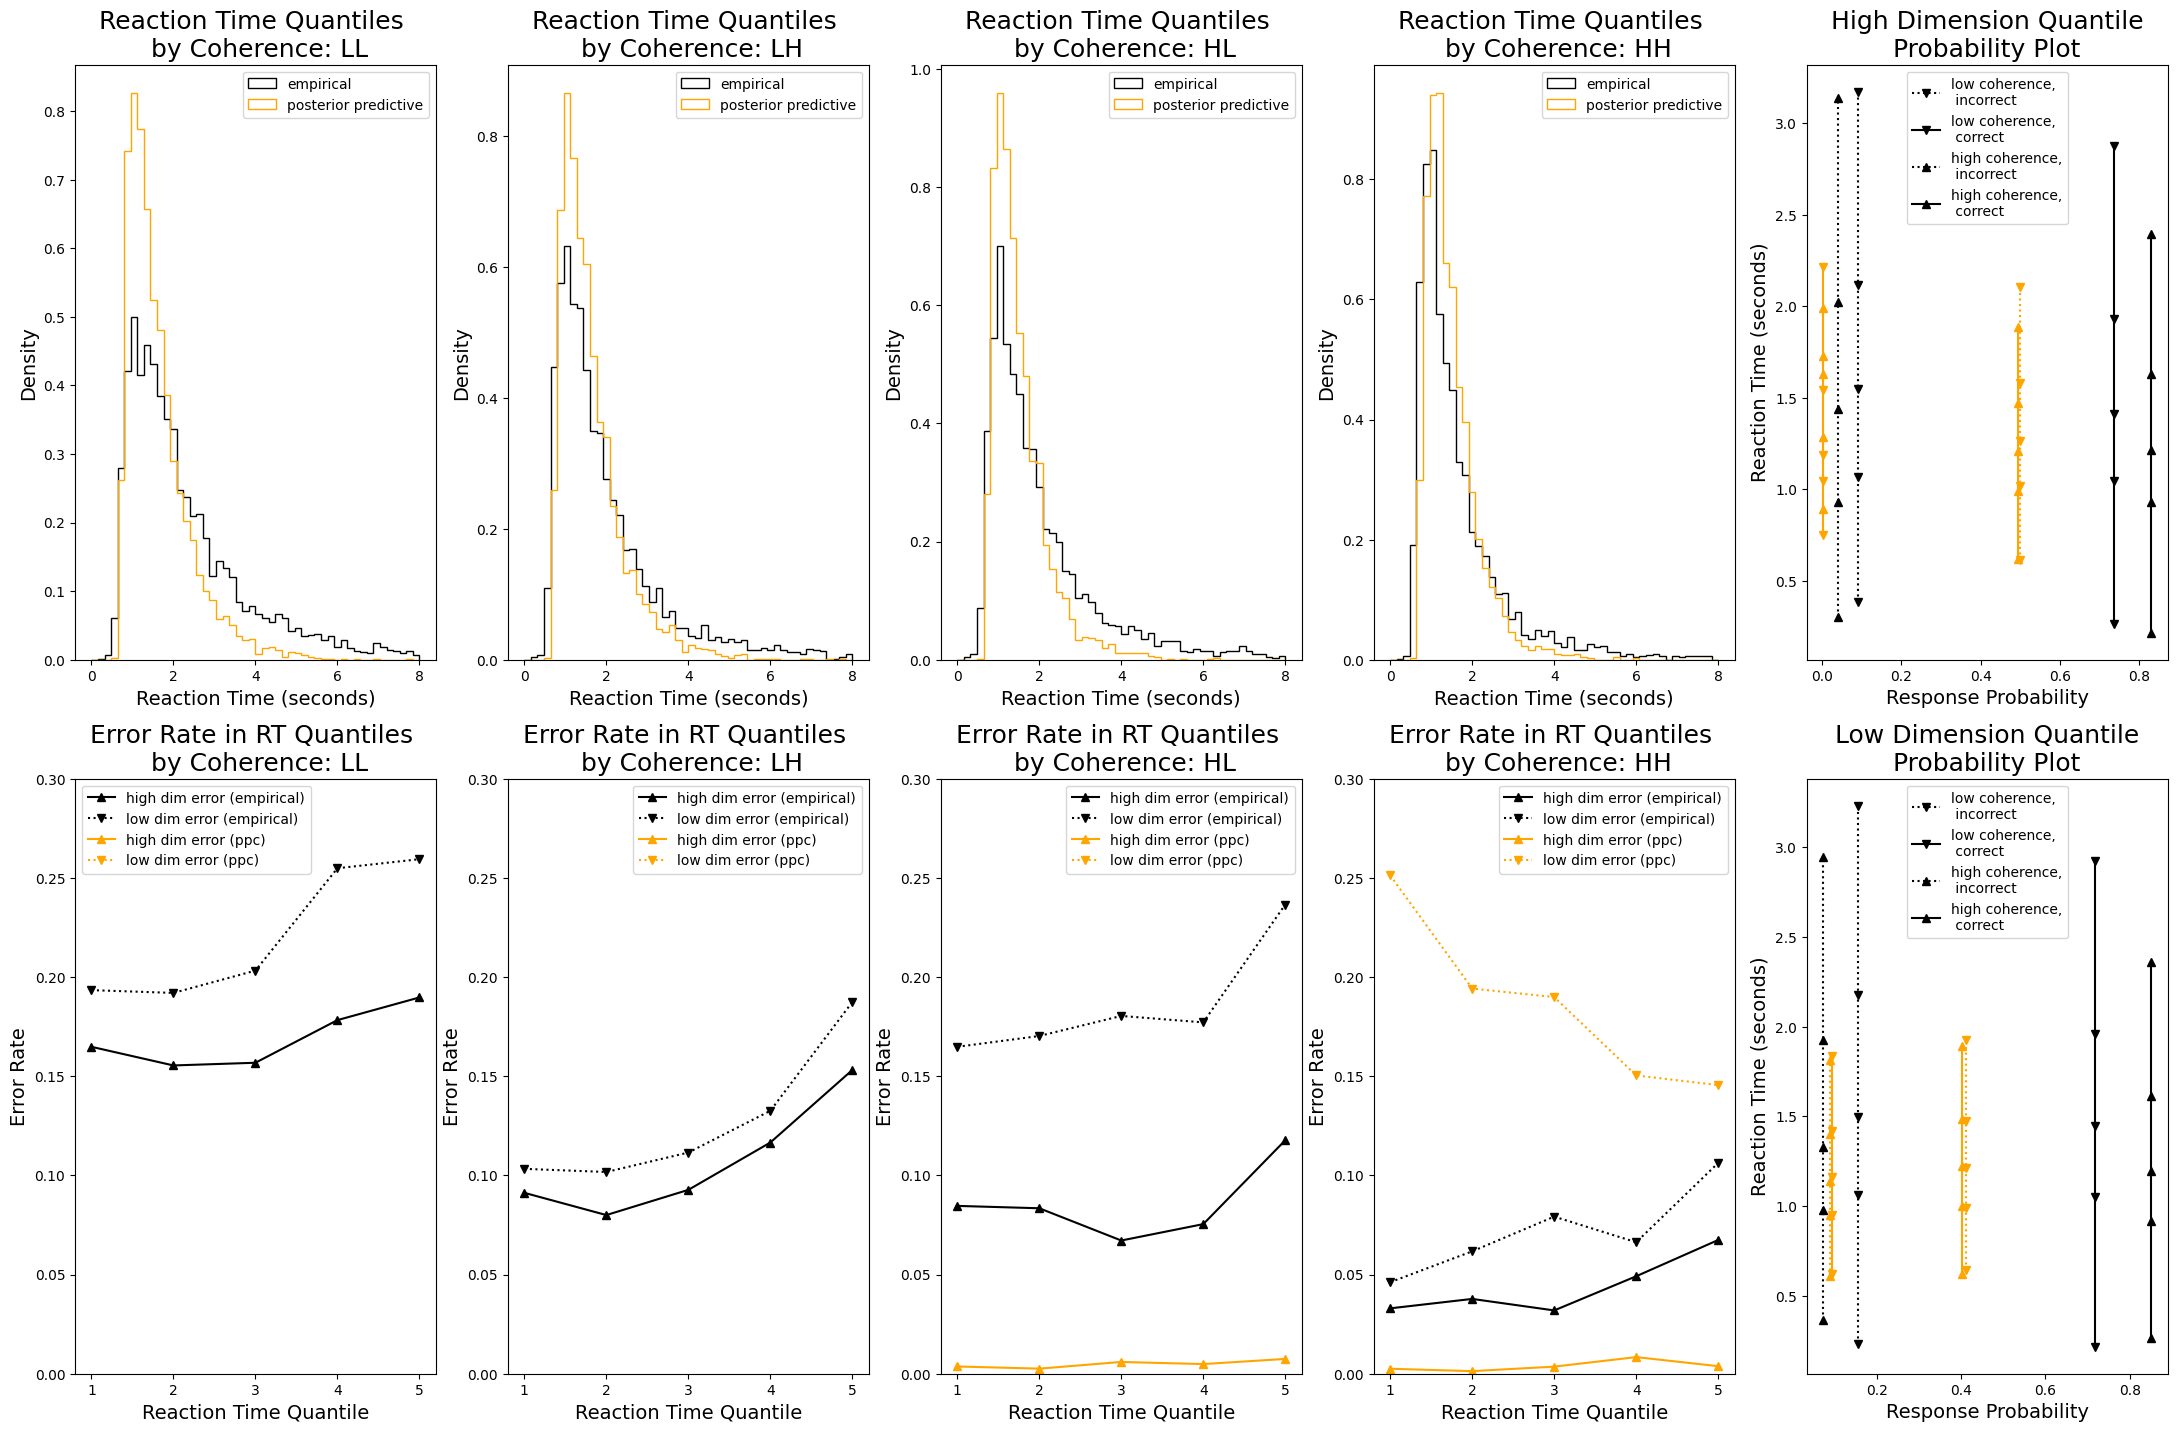

In [18]:
plt.figure(figsize=(27,17))
all_plots_with_real([final_df])

In [21]:
highDimCohLow = final_df[final_df['highDimCoh'] == -1]
lowCohCorrect = highDimCohLow[highDimCohLow['response'] == 3]
lowCohIncorrect = highDimCohLow[highDimCohLow['response'] == 1]

highDimCohHigh = final_df[final_df['highDimCoh'] == 1]
highCohIncorrect = highDimCohHigh[highDimCohHigh['response'] == 1]

In [22]:
highDimCohLow[highDimCohLow['response'] == 3]

,rxtime,response,subj,highDimCoh,irrDimCoh,lowDimCoh
385,0.812000,3,1,-1,1,1
341,3.780945,3,3,-1,1,1
310,1.472991,3,7,-1,1,1
323,2.212024,3,10,-1,1,1
305,1.187995,3,12,-1,1,1
404,1.135995,3,12,-1,-1,-1
443,1.295993,3,13,-1,-1,1
354,1.558993,3,18,-1,-1,1
417,1.043997,3,18,-1,-1,1
480,0.749000,3,18,-1,-1,-1


In [23]:
final_df

,rxtime,response,subj,highDimCoh,irrDimCoh,lowDimCoh
0,2.100019,1,0,-1,1,-1
1,1.529992,1,0,-1,-1,-1
2,1.302993,3,0,1,1,1
3,1.257994,2,0,1,-1,-1
4,0.899998,1,0,-1,-1,1
...,...,...,...,...,...,...
507,1.209994,3,31,1,1,1
508,1.654998,1,31,-1,-1,1
509,2.338030,3,31,1,-1,1
510,1.748002,0,31,-1,-1,-1


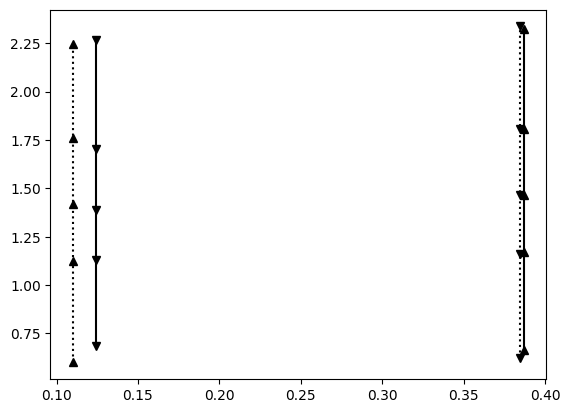

In [35]:
single_qpp(final_df, 5, 'black', coh_level='lowDim')

In [ ]:
final

0.038461538461538464
0.04
0.038461538461538464
0.24
0.16
0.5
0.48
0.46153846153846156
0.32
0.28
0.0
0.0
0.0
0.0
0.04
0.23076923076923078
0.16
0.15384615384615385
0.08
0.12
0.07692307692307693
0.0
0.15384615384615385
0.2
0.2
0.19230769230769232
0.16
0.038461538461538464
0.08
0.24
0.15384615384615385
0.2
0.07692307692307693
0.12
0.2
0.15384615384615385
0.28
0.23076923076923078
0.2
0.2
0.038461538461538464
0.04
0.0
0.12
0.08
0.07692307692307693
0.08
0.038461538461538464
0.0
0.0
0.07692307692307693
0.0
0.0
0.0
0.0
0.11538461538461539
0.08
0.11538461538461539
0.24
0.36
0.19230769230769232
0.12
0.07692307692307693
0.0
0.2
0.07692307692307693
0.0
0.038461538461538464
0.12
0.04
0.07692307692307693
0.12
0.04
0.08
0.12
0.038461538461538464
0.08
0.11538461538461539
0.16
0.08
0.038461538461538464
0.12
0.11538461538461539
0.04
0.0
0.0
0.0
0.0
0.04
0.0
0.0
0.08
0.0
0.12
0.16
0.15384615384615385
0.12
0.12
0.12
0.12
0.038461538461538464
0.08
0.07692307692307693
0.12
0.04
0.34615384615384615
0.16
0.192

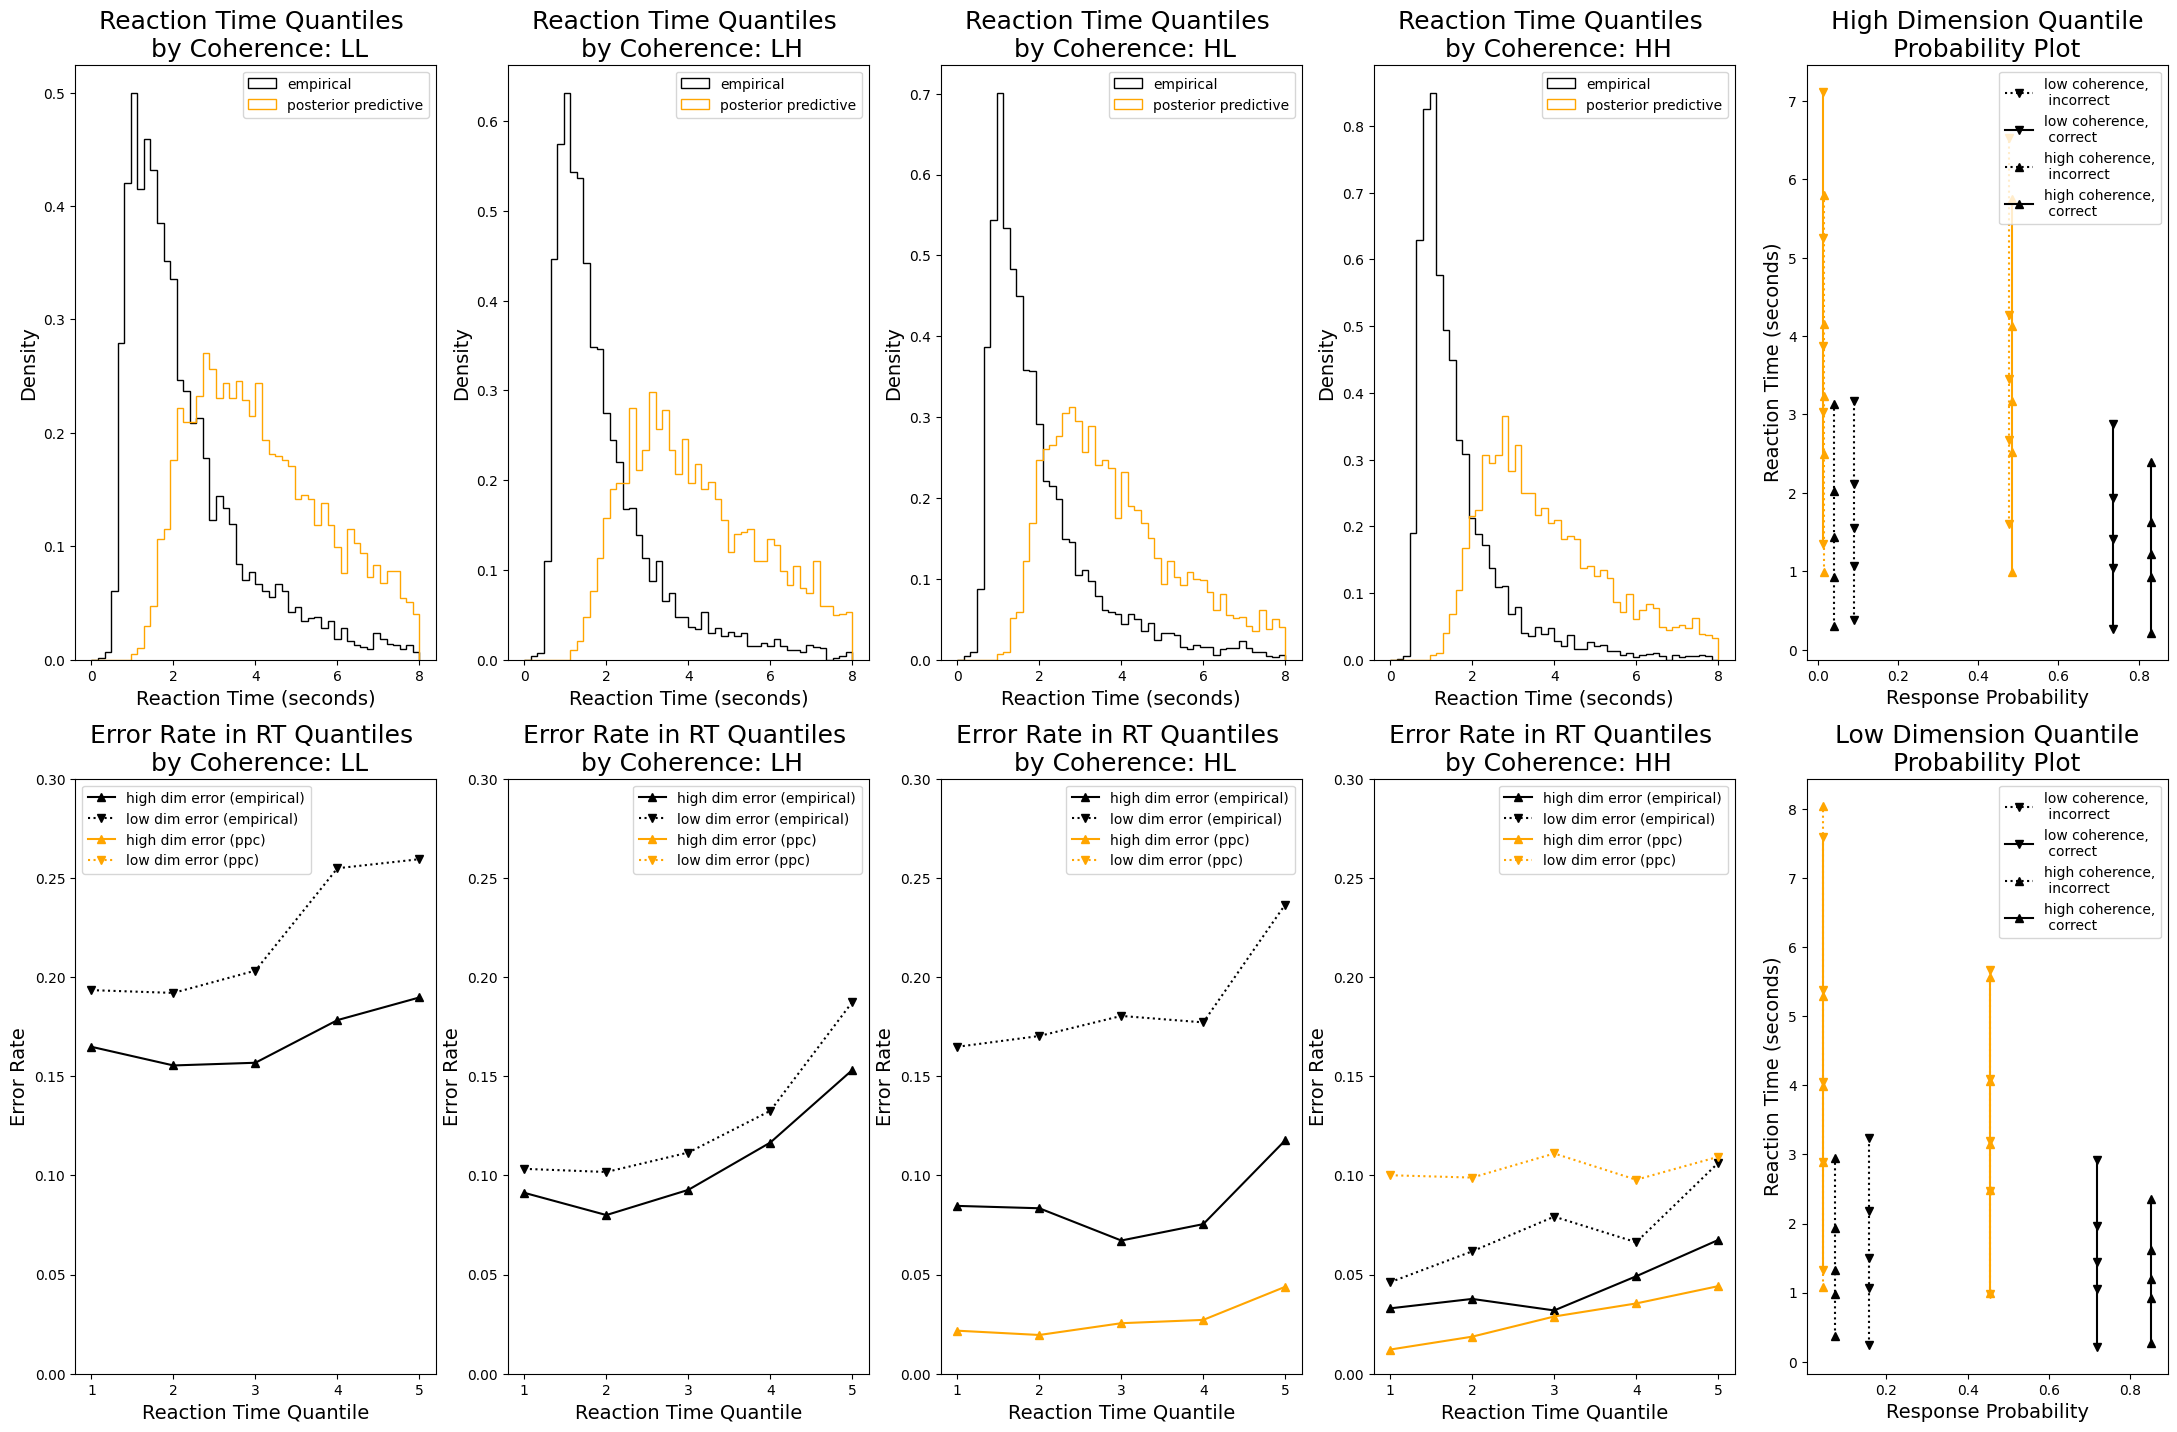

In [16]:
create_list_by_condition([final_df], -1, -1)

[Empty DataFrame
 Columns: [rxtime, response, subj, highDimCoh, irrDimCoh, lowDimCoh]
 Index: []]

[nan nan nan nan nan]
[nan nan nan nan nan]
[nan nan nan nan nan]
[nan nan nan nan nan]
[nan nan nan nan nan]
[nan nan nan nan nan]
[nan nan nan nan nan]
[nan nan nan nan nan]
[nan nan nan nan nan]
[nan nan nan nan nan]
[nan nan nan nan nan]
[nan nan nan nan nan]
[nan nan nan nan nan]
[nan nan nan nan nan]
[nan nan nan nan nan]
[nan nan nan nan nan]


/oscar/home/avo2/mambaforge/envs/hssm_vi2/lib/python3.11/site-packages/numpy/lib/histograms.py:885: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges
/oscar/home/avo2/mambaforge/envs/hssm_vi2/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/oscar/home/avo2/mambaforge/envs/hssm_vi2/lib/python3.11/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/oscar/home/avo2/mambaforge/envs/hssm_vi2/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/oscar/home/avo2/mambaforge/envs/hssm_vi2/lib/python3.11/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/oscar/home/avo2/mambaforge/envs/hssm_vi2/lib/python3.11/site-packages/numpy/core/f

ZeroDivisionError: division by zero

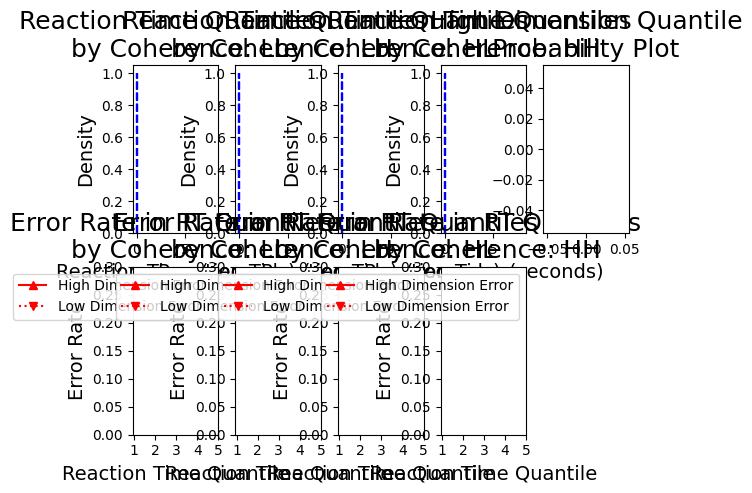

In [13]:
all_plots(final_df)